# 🌏 Analisis Realisasi Investasi Asing (FDI) Indonesia 2019–2023
### *Dampak Pandemi COVID-19 terhadap Penanaman Modal Luar Negeri Menurut Sektor Ekonomi*

---
> **Sumber Data:** BKPM — Realisasi Investasi Penanaman Modal Luar Negeri Triwulanan Menurut Sektor Ekonomi (Juta US$)
>
> **Periode:** 2019 (pra-pandemi) → 2020 (puncak pandemi) → 2021–2022 (pemulihan) → 2023 (pasca-pandemi)


In [ ]:
# ============================================================
# CELL 1: Import Library
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.alpha'] = 0.8

# Palette
COLORS = {
    2019: '#58a6ff',   # biru — pra-pandemi
    2020: '#f85149',   # merah — pandemi
    2021: '#ffa657',   # oranye — awal pemulihan
    2022: '#3fb950',   # hijau — pemulihan kuat
    2023: '#d2a8ff',   # ungu — pasca-pandemi
}
ERA_LABELS = {
    2019: 'Pra-Pandemi',
    2020: 'Puncak Pandemi',
    2021: 'Awal Pemulihan',
    2022: 'Pemulihan Kuat',
    2023: 'Pasca-Pandemi',
}

print('✅ Library berhasil di-import.')

✅ Library berhasil di-import.


In [ ]:
# ============================================================
# CELL 2: Load & Parsing Data
# ============================================================

# Updated filenames to match the actual files in /content/
FILES = {
    2019: 'Realisasi Investasi Penanaman Modal Luar Negeri Triwulanan Menurut Sektor Ekonomi - Jumlah Investasi, 2019.csv',
    2020: 'Realisasi Investasi Penanaman Modal Luar Negeri Triwulanan Menurut Sektor Ekonomi - Jumlah Investasi, 2020.csv',
    2021: 'Realisasi Investasi Penanaman Modal Luar Negeri Triwulanan Menurut Sektor Ekonomi - Jumlah Investasi, 2021.csv',
    2022: 'Realisasi Investasi Penanaman Modal Luar Negeri Triwulanan Menurut Sektor Ekonomi - Jumlah Investasi, 2022.csv',
    2023: 'Realisasi Investasi Penanaman Modal Luar Negeri Triwulanan Menurut Sektor Ekonomi - Jumlah Investasi, 2023.csv',
}

def load_fdi_csv(filepath, year):
    """Parse CSV FDI dengan format header multi-baris."""
    df = pd.read_csv(filepath, skiprows=4, header=None, encoding='utf-8-sig')
    df.columns = ['sektor', 'Q1', 'Q2', 'Q3', 'Q4', 'tahunan']
    df = df[df['sektor'].notna()].copy()
    df = df[~df['sektor'].str.upper().str.startswith('JUMLAH')].copy()
    for col in ['Q1', 'Q2', 'Q3', 'Q4', 'tahunan']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['tahun'] = year
    # Bersihkan nama sektor
    df['sektor'] = df['sektor'].str.replace(r'^\d+\.\s*', '', regex=True).str.strip()
    return df.dropna(subset=['Q1', 'Q2', 'Q3', 'Q4'])

# Load semua tahun
frames = []
for year, fname in FILES.items():
    try:
        # Ensure we point to the correct directory /content/
        df = load_fdi_csv(f'/content/{fname}', year)
        frames.append(df)
        print(f'✅ {year}: {len(df)} sektor dimuat')
    except FileNotFoundError:
        print(f'❌ File {year} tidak ditemukan. Periksa nama file di folder /content/')

if frames:
    df_all = pd.concat(frames, ignore_index=True)
    print(f'\n📊 Total baris data: {len(df_all)}')
    display(df_all.head())
else:
    print('❌ Tidak ada data yang berhasil dimuat.')

✅ 2019: 23 sektor dimuat
✅ 2020: 23 sektor dimuat
✅ 2021: 23 sektor dimuat
✅ 2022: 23 sektor dimuat
✅ 2023: 23 sektor dimuat

📊 Total baris data: 115


,sektor,Q1,Q2,Q3,Q4,tahunan,tahun
0,"Tanaman Pangan, Perkebunan, dan Peternakan",217.10,288.30,226.20,215.30,946.90,2019
1,Kehutanan,0.40,4.70,17.00,14.20,36.30,2019
2,Perikanan,3.90,34.00,4.40,11.80,54.10,2019
3,Pertambangan,614.60,672.40,285.60,683.70,"2,256.30",2019
4,Industri Makanan,383.20,323.50,296.10,269.30,"1,272.20",2019


In [ ]:
# ============================================================
# CELL 3: Statistik Deskriptif per Tahun
# ============================================================

# Gunakan nilai tahunan per sektor
stats_table = []
for year in sorted(df_all['tahun'].unique()):
    data = df_all[df_all['tahun'] == year]['tahunan'].dropna()
    total = df_all[df_all['tahun'] == year][['Q1','Q2','Q3','Q4']].sum().sum()
    stats_table.append({
        'Tahun': year,
        'Era': ERA_LABELS[year],
        'Total FDI (Juta US$)': round(total, 1),
        'Mean per Sektor': round(data.mean(), 2),
        'Median per Sektor': round(data.median(), 2),
        'Std Dev': round(data.std(), 2),
        'Min': round(data.min(), 2),
        'Max': round(data.max(), 2),
        'Skewness': round(data.skew(), 3),
        'Kurtosis': round(data.kurtosis(), 3),
        'Q25 (Juta US$)': round(data.quantile(0.25), 2),
        'Q75 (Juta US$)': round(data.quantile(0.75), 2),
        'IQR': round(data.quantile(0.75) - data.quantile(0.25), 2),
    })

stats_df = pd.DataFrame(stats_table).set_index('Tahun')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
print('\nSTATISTIK DESKRIPTIF FDI INDONESIA 2019–2023')
print('=' * 80)
stats_df


STATISTIK DESKRIPTIF FDI INDONESIA 2019–2023


,Era,Total FDI (Juta US$),Mean per Sektor,Median per Sektor,Std Dev,Min,Max,Skewness,Kurtosis,Q25 (Juta US$),Q75 (Juta US$),IQR
Tahun,,,,,,,,,,,,
2019,Pra-Pandemi,"28,208.70","1,226.47",499.80,"1,597.00",36.30,"5,921.20",1.86,2.85,242.10,"1,379.15","1,137.05"
2020,Puncak Pandemi,"28,666.00","1,246.35",601.30,"1,556.07",42.60,"5,969.20",1.92,3.37,264.05,"1,667.30","1,403.25"
2021,Awal Pemulihan,"31,092.40","1,351.87",679.40,"1,647.48",17.10,"6,974.40",2.09,5.25,287.20,"1,921.40","1,634.20"
2022,Pemulihan Kuat,"45,605.10","1,982.82",788.80,"2,487.79",31.60,"10,960.60",2.39,7.07,456.50,"2,719.60","2,263.10"
2023,Pasca-Pandemi,"50,267.30","2,185.54","1,478.40","2,643.16",25.70,"11,787.20",2.43,7.37,490.45,"2,658.30","2,167.85"


In [ ]:
# ============================================================
# CELL 4: Ringkasan Naratif Statistik
# ============================================================

total_2019 = stats_df.loc[2019, 'Total FDI (Juta US$)']
total_2020 = stats_df.loc[2020, 'Total FDI (Juta US$)']
total_2023 = stats_df.loc[2023, 'Total FDI (Juta US$)']
growth_2019_2023 = ((total_2023 - total_2019) / total_2019) * 100
change_2020 = ((total_2020 - total_2019) / total_2019) * 100

print('━' * 70)
print('📝 RINGKASAN NARATIF STATISTIK')
print('━' * 70)
print(f"""
🔵 [2019 — Pra-Pandemi]
   Total FDI mencapai US${total_2019:,.1f} juta sebagai baseline pra-pandemi.
   Distribusi antar sektor cukup merata, didominasi oleh sektor Listrik, Gas &
   Air serta Transportasi & Telekomunikasi.

🔴 [2020 — Puncak Pandemi COVID-19]
   Total FDI: US${total_2020:,.1f} juta ({change_2020:+.1f}% dari 2019).
   Meski total tahunan relatif stabil, distribusi triwulanan menunjukkan guncangan:
   Q1 turun signifikan akibat lockdown global, namun Q4 rebound karena adaptasi.
   Standar deviasi meningkat → volatilitas tinggi antar sektor.

🟠 [2021 — Awal Pemulihan]
   Pemulihan mulai terlihat dengan total FDI US${stats_df.loc[2021, 'Total FDI (Juta US$)']:,.1f} juta.
   Sektor manufaktur dan digital mulai menarik investasi lebih besar.

🟢 [2022 — Pemulihan Kuat]
   Lonjakan luar biasa ke US${stats_df.loc[2022, 'Total FDI (Juta US$)']:,.1f} juta.
   Ini adalah tahun pembalikan struktural — Indonesia menjadi tujuan investasi
   besar di sektor hilirisasi mineral dan energi terbarukan.

🟣 [2023 — Pasca-Pandemi]
   FDI menembus US${total_2023:,.1f} juta, tumbuh {growth_2019_2023:.1f}% dari baseline 2019.
   Pandemi justru menjadi katalis percepatan investasi jangka panjang.
""")
print('━' * 70)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📝 RINGKASAN NARATIF STATISTIK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔵 [2019 — Pra-Pandemi]
   Total FDI mencapai US$28,208.7 juta sebagai baseline pra-pandemi.
   Distribusi antar sektor cukup merata, didominasi oleh sektor Listrik, Gas &
   Air serta Transportasi & Telekomunikasi.

🔴 [2020 — Puncak Pandemi COVID-19]
   Total FDI: US$28,666.0 juta (+1.6% dari 2019).
   Meski total tahunan relatif stabil, distribusi triwulanan menunjukkan guncangan:
   Q1 turun signifikan akibat lockdown global, namun Q4 rebound karena adaptasi.
   Standar deviasi meningkat → volatilitas tinggi antar sektor.

🟠 [2021 — Awal Pemulihan]
   Pemulihan mulai terlihat dengan total FDI US$31,092.4 juta.
   Sektor manufaktur dan digital mulai menarik investasi lebih besar.

🟢 [2022 — Pemulihan Kuat]
   Lonjakan luar biasa ke US$45,605.1 juta.
   Ini adalah tahun pembalikan struktural — Indonesia menjadi tuju

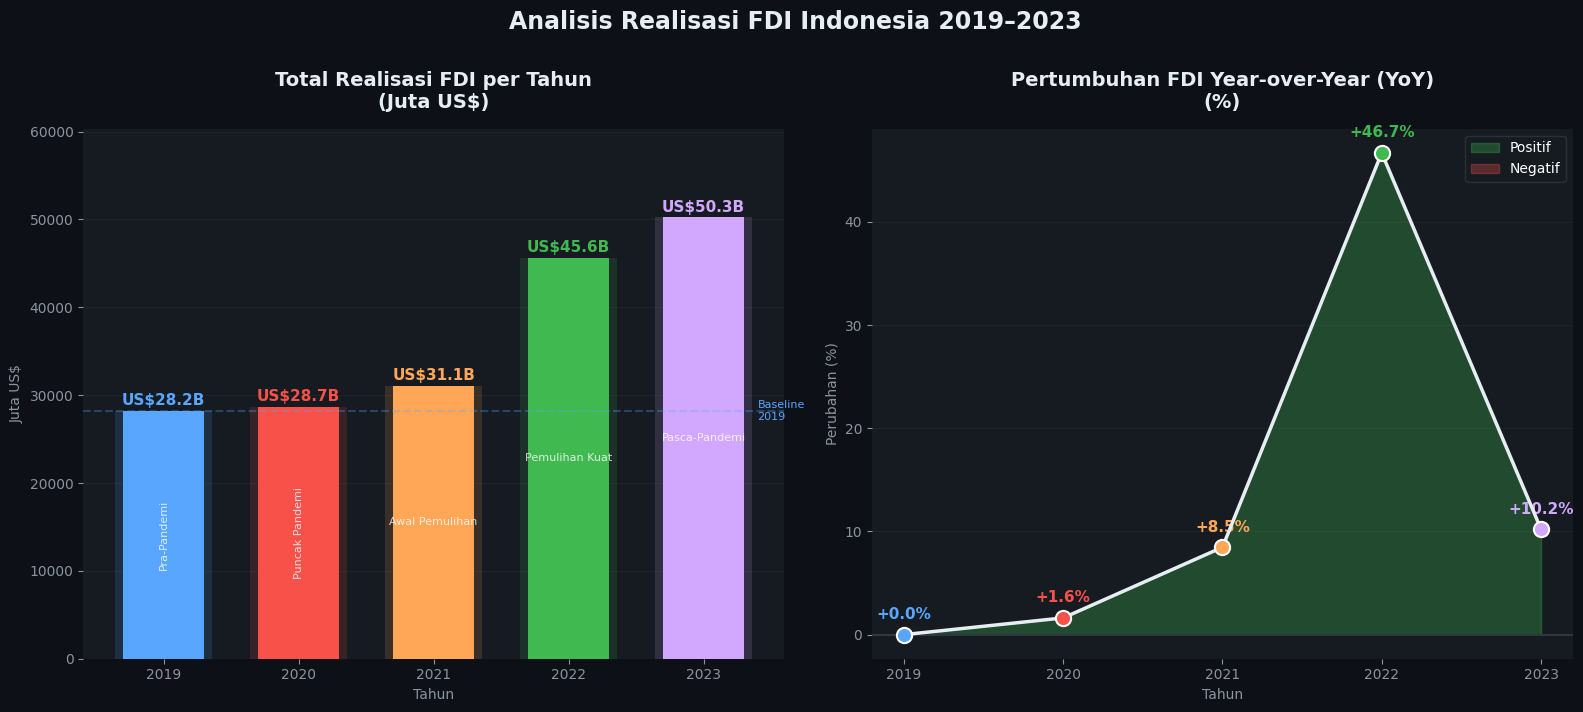

💾 Disimpan: viz1_total_fdi.png


In [ ]:
# ============================================================
# CELL 5: VISUALISASI 1 — Total FDI Tahunan + Pertumbuhan
# ============================================================

years = [2019, 2020, 2021, 2022, 2023]
totals = [stats_df.loc[y, 'Total FDI (Juta US$)'] for y in years]
growth = [0] + [((totals[i] - totals[i-1]) / totals[i-1]) * 100 for i in range(1, 5)]
bar_colors = [COLORS[y] for y in years]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

# --- Bar Chart: Total FDI ---
ax1.set_facecolor('#161b22')
bars = ax1.bar(years, totals, color=bar_colors, width=0.6, zorder=3,
               edgecolor='none', linewidth=0)

# Tambah glow effect
for bar, color in zip(bars, bar_colors):
    ax1.bar(bar.get_x() + bar.get_width()/2, bar.get_height(),
            width=bar.get_width() * 1.2, alpha=0.15, color=color, zorder=2)

for bar, val, y in zip(bars, totals, years):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 300,
             f'US${val/1000:.1f}B', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=COLORS[y])
    ax1.text(bar.get_x() + bar.get_width()/2, val/2,
             ERA_LABELS[y], ha='center', va='center',
             fontsize=8, color='white', alpha=0.8,
             rotation=90 if val < 30000 else 0)

ax1.set_title('Total Realisasi FDI per Tahun\n(Juta US$)',
              color='#e6edf3', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Tahun', color='#8b949e')
ax1.set_ylabel('Juta US$', color='#8b949e')
ax1.set_ylim(0, max(totals) * 1.2)
ax1.grid(axis='y', color='#21262d', linewidth=0.8, zorder=1)
ax1.spines[['top','right','left','bottom']].set_visible(False)
ax1.set_xticks(years)

# Anotasi pandemi
ax1.axhline(totals[0], color='#58a6ff', linestyle='--', alpha=0.3, zorder=4)
ax1.text(2023.4, totals[0], 'Baseline\n2019', color='#58a6ff', fontsize=8, va='center')

# --- Line Chart: Pertumbuhan YoY ---
ax2.set_facecolor('#161b22')
ax2.plot(years, growth, 'o-', color='#e6edf3', linewidth=2.5,
         markersize=10, zorder=5)
ax2.fill_between(years, growth, 0,
                  where=[g >= 0 for g in growth],
                  alpha=0.3, color='#3fb950', zorder=3, label='Positif')
ax2.fill_between(years, growth, 0,
                  where=[g < 0 for g in growth],
                  alpha=0.3, color='#f85149', zorder=3, label='Negatif')

for x, g, c in zip(years, growth, bar_colors):
    ax2.scatter(x, g, color=c, s=120, zorder=6, edgecolors='white', linewidths=1.5)
    offset = 1.5 if g >= 0 else -2.5
    ax2.text(x, g + offset, f'{g:+.1f}%', ha='center',
             color=c, fontsize=11, fontweight='bold')

ax2.axhline(0, color='#30363d', linewidth=1.5, zorder=4)
ax2.set_title('Pertumbuhan FDI Year-over-Year (YoY)\n(%)',
              color='#e6edf3', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Tahun', color='#8b949e')
ax2.set_ylabel('Perubahan (%)', color='#8b949e')
ax2.grid(axis='y', color='#21262d', linewidth=0.8)
ax2.spines[['top','right','left','bottom']].set_visible(False)
ax2.set_xticks(years)
ax2.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='white')

plt.suptitle('Analisis Realisasi FDI Indonesia 2019–2023',
             color='#e6edf3', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz1_total_fdi.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('💾 Disimpan: viz1_total_fdi.png')

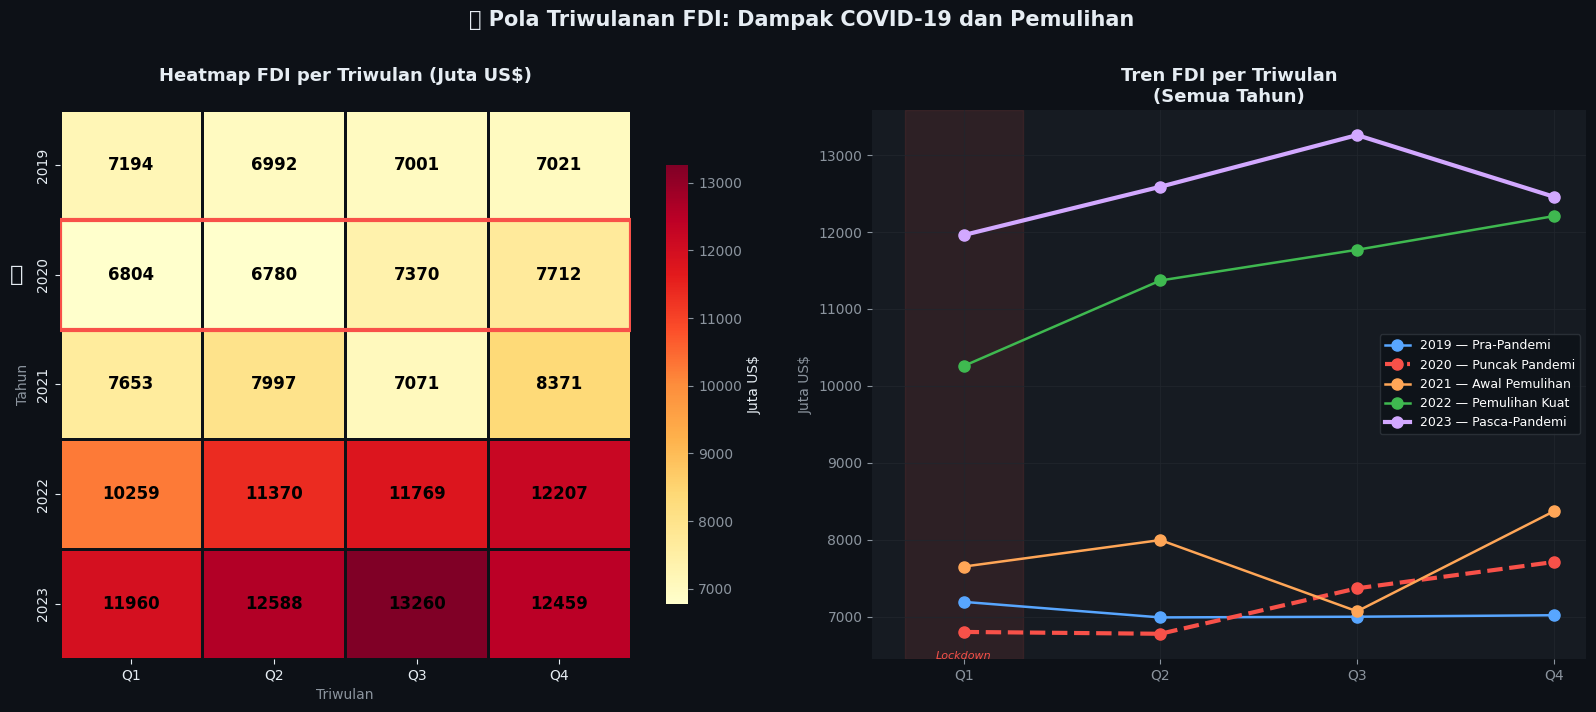

💾 Disimpan: viz2_quarterly.png


In [ ]:
# ============================================================
# CELL 6: VISUALISASI 2 — Tren Triwulanan (Quarterly Heatmap)
# ============================================================

# Ambil total per triwulan
quarterly_data = {}
for year in years:
    sub = df_all[df_all['tahun'] == year]
    quarterly_data[year] = {
        'Q1': sub['Q1'].sum(),
        'Q2': sub['Q2'].sum(),
        'Q3': sub['Q3'].sum(),
        'Q4': sub['Q4'].sum(),
    }

q_df = pd.DataFrame(quarterly_data).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

# --- Heatmap ---
ax1.set_facecolor('#0d1117')
cmap = sns.diverging_palette(10, 133, as_cmap=True)
sns.heatmap(q_df, ax=ax1, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=2, linecolor='#0d1117',
            annot_kws={'size': 12, 'color': 'black', 'weight': 'bold'},
            cbar_kws={'label': 'Juta US$', 'shrink': 0.8})

ax1.set_title('Heatmap FDI per Triwulan (Juta US$)\n',
              color='#e6edf3', fontsize=13, fontweight='bold')
ax1.set_xlabel('Triwulan', color='#8b949e')
ax1.set_ylabel('Tahun', color='#8b949e')
ax1.tick_params(colors='#e6edf3')

# Highlight baris 2020
ax1.add_patch(plt.Rectangle((0, 1), 4, 1, fill=False,
              edgecolor='#f85149', linewidth=3, zorder=10))
ax1.text(-0.3, 1.5, '🦠', ha='center', va='center', fontsize=16)

# --- Line Chart Quarterly ---
ax2.set_facecolor('#161b22')
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
x = np.arange(4)

for year in years:
    vals = [q_df.loc[year, q] for q in quarters]
    style = '--' if year == 2020 else '-'
    lw = 3 if year in [2020, 2023] else 1.8
    ax2.plot(x, vals, style, color=COLORS[year], linewidth=lw,
             label=f'{year} — {ERA_LABELS[year]}',
             marker='o', markersize=8)

# Shade pandemi
ax2.axvspan(-0.3, 0.3, alpha=0.1, color='#f85149', zorder=1)
ax2.text(0, ax2.get_ylim()[0] if ax2.get_ylim()[0] > 0 else 5000,
         'Lockdown', ha='center', color='#f85149', fontsize=8, style='italic')

ax2.set_title('Tren FDI per Triwulan\n(Semua Tahun)',
              color='#e6edf3', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(quarters)
ax2.set_ylabel('Juta US$', color='#8b949e')
ax2.grid(color='#21262d', linewidth=0.8)
ax2.spines[['top','right','left','bottom']].set_visible(False)
leg = ax2.legend(facecolor='#0d1117', edgecolor='#30363d',
                  labelcolor='white', fontsize=9)

plt.suptitle('📊 Pola Triwulanan FDI: Dampak COVID-19 dan Pemulihan',
             color='#e6edf3', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz2_quarterly.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('💾 Disimpan: viz2_quarterly.png')

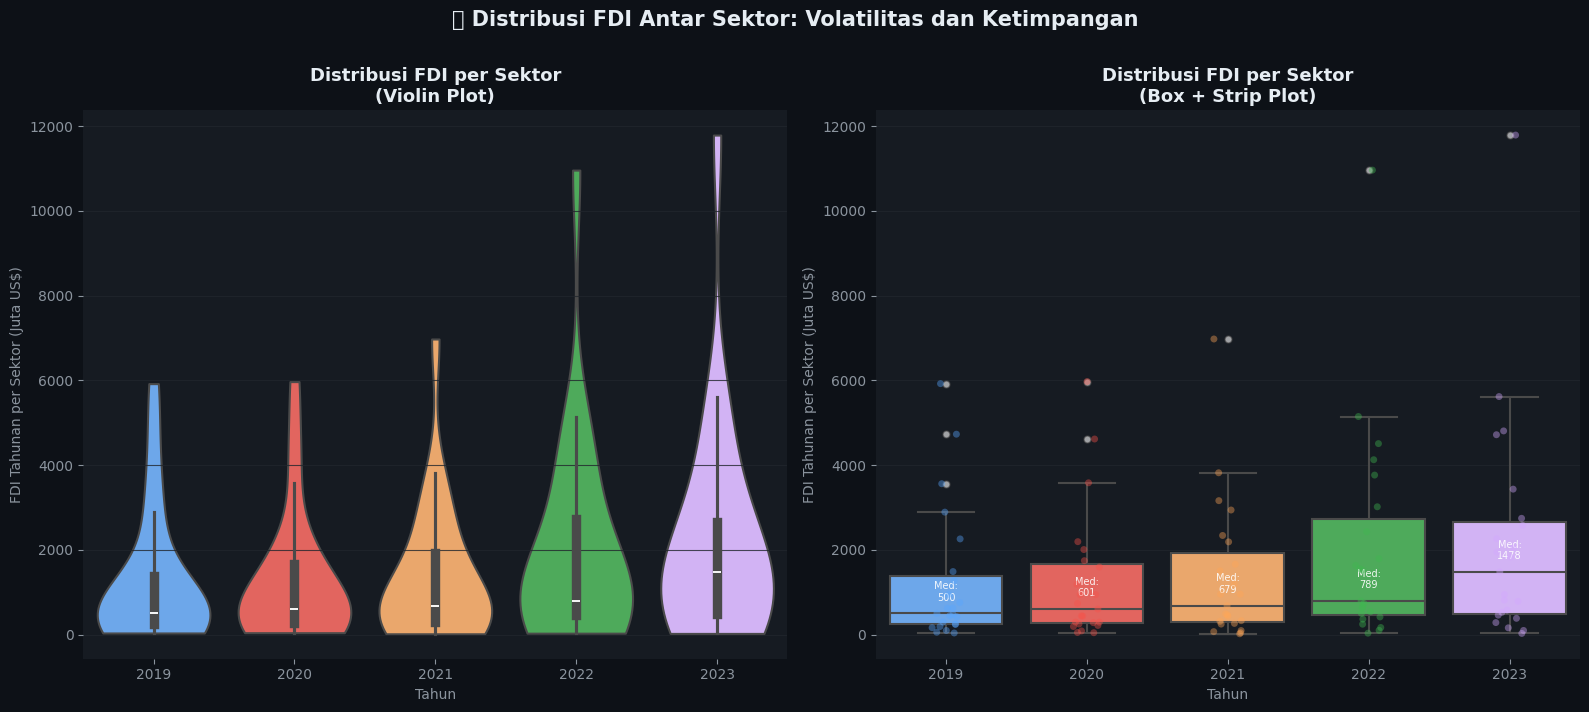

💾 Disimpan: viz3_distribusi.png


In [ ]:
# ============================================================
# CELL 7: VISUALISASI 3 — Distribusi FDI per Sektor (Box + Violin)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

plot_data = []
for year in years:
    vals = df_all[df_all['tahun'] == year]['tahunan'].dropna().tolist()
    for v in vals:
        plot_data.append({'Tahun': str(year), 'FDI': v, 'Era': ERA_LABELS[year]})
plot_df = pd.DataFrame(plot_data)

palette = {str(y): COLORS[y] for y in years}

# --- Violin Plot ---
ax1 = axes[0]
ax1.set_facecolor('#161b22')
vp = sns.violinplot(data=plot_df, x='Tahun', y='FDI', palette=palette,
                     ax=ax1, inner='box', linewidth=1.5, cut=0)
ax1.set_title('Distribusi FDI per Sektor\n(Violin Plot)',
              color='#e6edf3', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tahun', color='#8b949e')
ax1.set_ylabel('FDI Tahunan per Sektor (Juta US$)', color='#8b949e')
ax1.grid(axis='y', color='#21262d', linewidth=0.8)
ax1.spines[['top','right','left','bottom']].set_visible(False)

# --- Box Plot ---
ax2 = axes[1]
ax2.set_facecolor('#161b22')
bp = sns.boxplot(data=plot_df, x='Tahun', y='FDI', palette=palette,
                  ax=ax2, linewidth=1.5, flierprops=dict(marker='o', markersize=5,
                  markerfacecolor='white', alpha=0.6))
sns.stripplot(data=plot_df, x='Tahun', y='FDI', palette=palette,
               ax=ax2, alpha=0.4, size=5, jitter=True, zorder=10)

# Tambahkan stat
for i, year in enumerate(years):
    med = stats_df.loc[year, 'Median per Sektor']
    ax2.text(i, med + 300, f'Med:\n{med:.0f}', ha='center',
             color='white', fontsize=7, alpha=0.9)

ax2.set_title('Distribusi FDI per Sektor\n(Box + Strip Plot)',
              color='#e6edf3', fontsize=13, fontweight='bold')
ax2.set_xlabel('Tahun', color='#8b949e')
ax2.set_ylabel('FDI Tahunan per Sektor (Juta US$)', color='#8b949e')
ax2.grid(axis='y', color='#21262d', linewidth=0.8)
ax2.spines[['top','right','left','bottom']].set_visible(False)

plt.suptitle('📦 Distribusi FDI Antar Sektor: Volatilitas dan Ketimpangan',
             color='#e6edf3', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz3_distribusi.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('💾 Disimpan: viz3_distribusi.png')

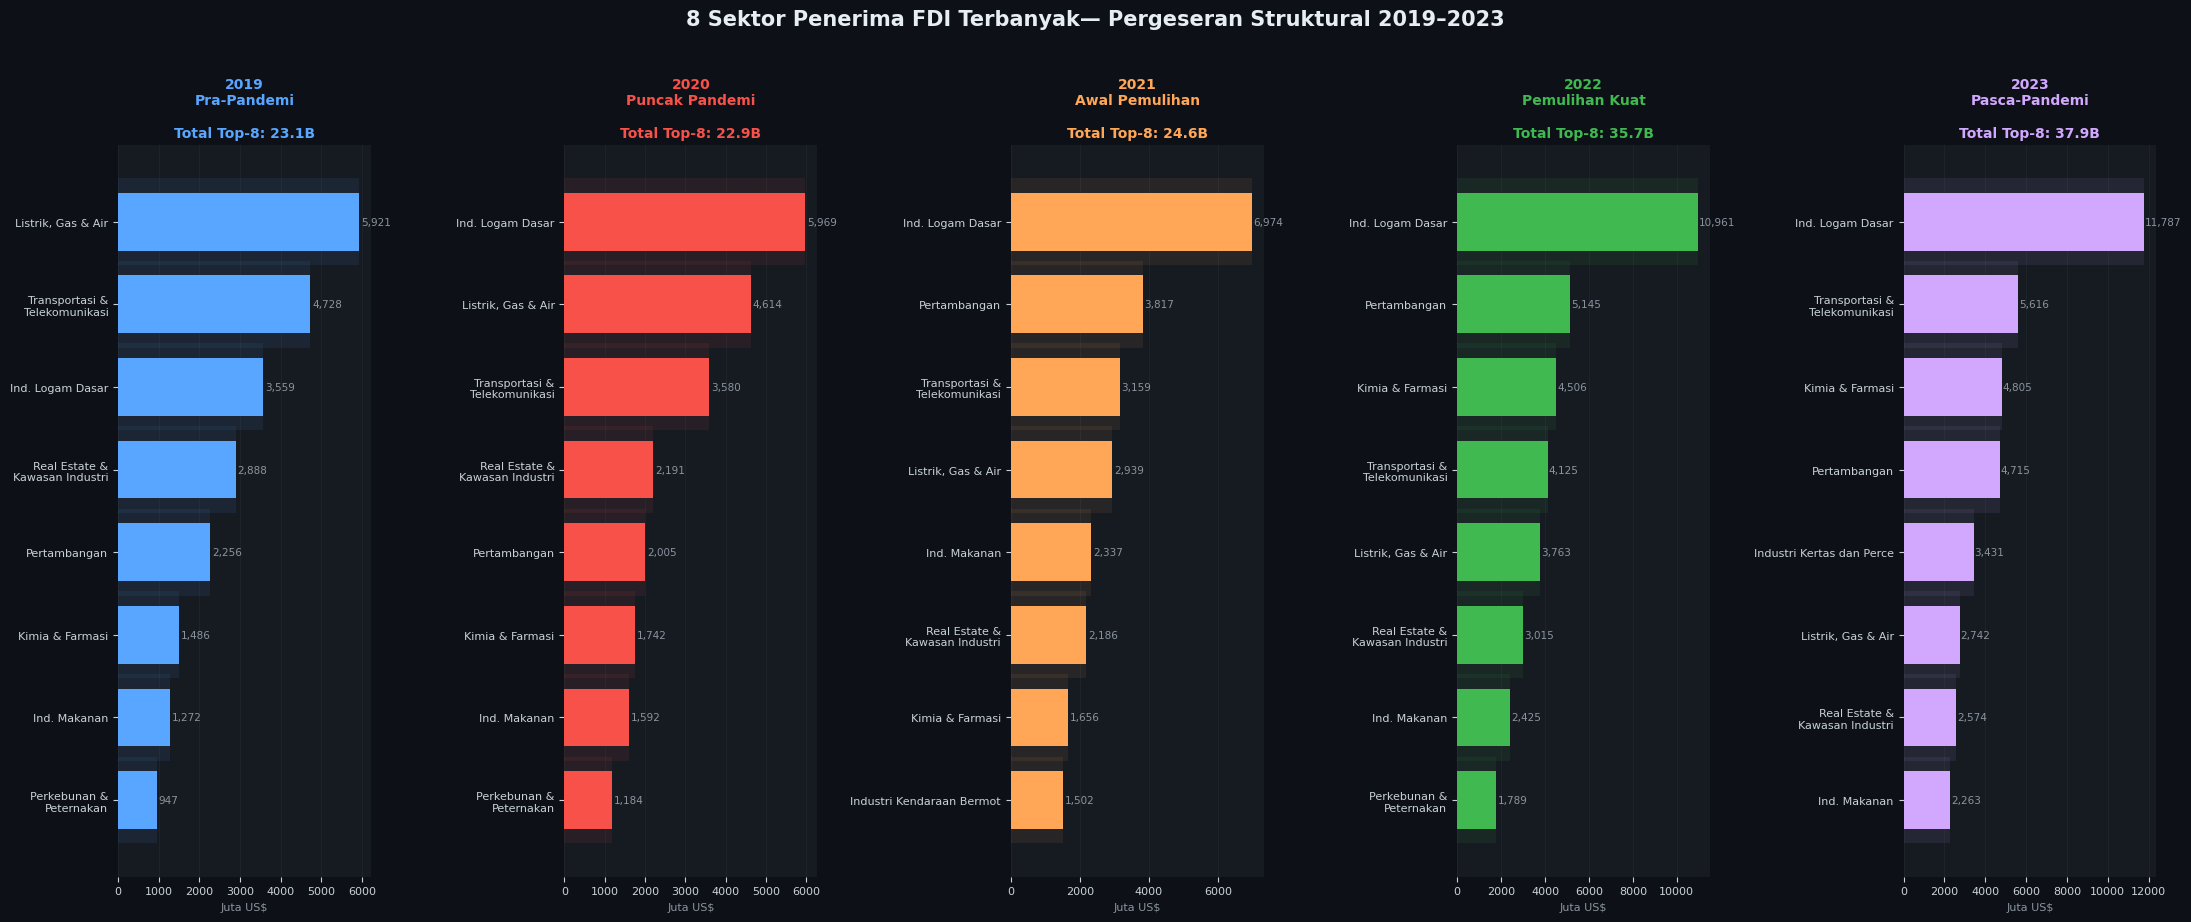

💾 Disimpan: viz4_top_sektor.png


In [ ]:
# ============================================================
# CELL 8: VISUALISASI 4 — Top 8 Sektor Dominan per Tahun
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(22, 9))
fig.patch.set_facecolor('#0d1117')

for ax, year in zip(axes, years):
    ax.set_facecolor('#161b22')
    sub = df_all[df_all['tahun'] == year][['sektor', 'tahunan']].dropna()
    sub = sub.nlargest(8, 'tahunan')
    sub = sub.sort_values('tahunan')

    # Shorten sektor names
    label_map = {
        'Listrik, Gas, dan Air': 'Listrik, Gas & Air',
        'Transportasi, Gudang, dan Telekomunikasi': 'Transportasi &\nTelekomunikasi',
        'Perumahan, Kawasan Industri, dan Perkantoran': 'Real Estate &\nKawasan Industri',
        'Industri Logam Dasar, Barang Logam, Bukan Mesin dan Peralatannya': 'Ind. Logam Dasar',
        'Tanaman Pangan, Perkebunan, dan Peternakan': 'Perkebunan &\nPeternakan',
        'Industri Kimia dan Farmasi': 'Kimia & Farmasi',
        'Industri Makanan': 'Ind. Makanan',
        'Industri Mineral Non Logam': 'Mineral Non Logam',
    }
    sub['label'] = sub['sektor'].apply(lambda x: label_map.get(x, x[:25]))

    colors_bar = [COLORS[year]] * len(sub)
    bars = ax.barh(sub['label'], sub['tahunan'], color=colors_bar,
                   edgecolor='none', height=0.7, zorder=3)

    # Glow
    for bar in bars:
        ax.barh(bar.get_y() + bar.get_height()/2, bar.get_width(),
                height=bar.get_height() * 1.5, left=0,
                alpha=0.08, color=COLORS[year], zorder=2)

    for bar, val in zip(bars, sub['tahunan']):
        ax.text(val + 50, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}', va='center', ha='left',
                fontsize=7.5, color='#8b949e')

    total = sub['tahunan'].sum()
    ax.set_title(f'{year}\n{ERA_LABELS[year]}\n\nTotal Top-8: {total/1000:.1f}B',
                 color=COLORS[year], fontsize=10, fontweight='bold')
    ax.set_xlabel('Juta US$', color='#8b949e', fontsize=8)
    ax.tick_params(labelsize=8, colors='#c9d1d9')
    ax.grid(axis='x', color='#21262d', linewidth=0.8, zorder=1)
    ax.spines[['top','right','left','bottom']].set_visible(False)

plt.suptitle('8 Sektor Penerima FDI Terbanyak— Pergeseran Struktural 2019–2023',
             color='#e6edf3', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz4_top_sektor.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('💾 Disimpan: viz4_top_sektor.png')

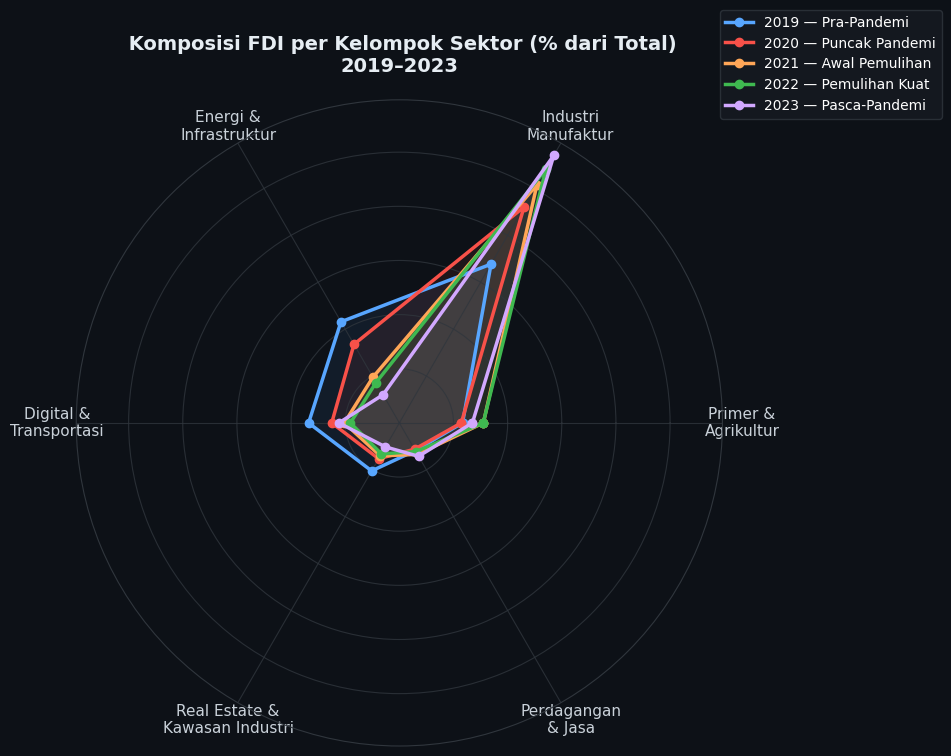

💾 Disimpan: viz5_radar.png


In [ ]:
# ============================================================
# CELL 9: VISUALISASI 5 — Radar Chart Komposisi Sektor
# ============================================================

from matplotlib.patches import Polygon
import matplotlib.patheffects as pe

# Kelompokkan sektor ke 6 kategori besar
KATEGORI = {
    'Primer &\nAgrikultur': ['Tanaman Pangan, Perkebunan, dan Peternakan',
                              'Kehutanan', 'Perikanan', 'Pertambangan'],
    'Industri\nManufaktur': ['Industri Makanan', 'Industri Tekstil',
                              'Industri Barang dari Kulit dan Alas Kaki',
                              'Industri Kayu', 'Industri Kertas dan Percetakan',
                              'Industri Kimia dan Farmasi', 'Industri Karet dan Plastik',
                              'Industri Mineral Non Logam',
                              'Industri Logam Dasar, Barang Logam, Bukan Mesin dan Peralatannya',
                              'Industri Mesin, Elektronik, Instrumen Kedokteran, Peralatan Listrik, Presisi, Optik dan Jam',
                              'Industri Kendaraan Bermotor dan Alat Transportasi Lain',
                              'Industri Lainnya'],
    'Energi &\nInfrastruktur': ['Listrik, Gas, dan Air', 'Konstruksi'],
    'Digital &\nTransportasi': ['Transportasi, Gudang, dan Telekomunikasi'],
    'Real Estate &\nKawasan Industri': ['Perumahan, Kawasan Industri, dan Perkantoran'],
    'Perdagangan\n& Jasa': ['Perdagangan dan Reparasi', 'Hotel dan Restoran', 'Jasa Lainnya'],
}

radar_data = {}
for year in years:
    sub = df_all[df_all['tahun'] == year]
    total = sub['tahunan'].sum()
    row = {}
    for kat, sektors in KATEGORI.items():
        val = sub[sub['sektor'].isin(sektors)]['tahunan'].sum()
        row[kat] = (val / total * 100)
    radar_data[year] = row

radar_df = pd.DataFrame(radar_data).T
categories = list(KATEGORI.keys())
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

for year in years:
    vals = [radar_df.loc[year, c] for c in categories]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2.5, color=COLORS[year],
            label=f'{year} — {ERA_LABELS[year]}')
    ax.fill(angles, vals, alpha=0.08, color=COLORS[year])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color='#c9d1d9', size=11)
ax.set_yticklabels([], color='#8b949e')
ax.spines['polar'].set_color('#30363d')
ax.grid(color='#30363d', linewidth=0.8)

leg = ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
                facecolor='#161b22', edgecolor='#30363d',
                labelcolor='white', fontsize=10)

ax.set_title(' Komposisi FDI per Kelompok Sektor (% dari Total)\n2019–2023',
             color='#e6edf3', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('viz5_radar.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('💾 Disimpan: viz5_radar.png')

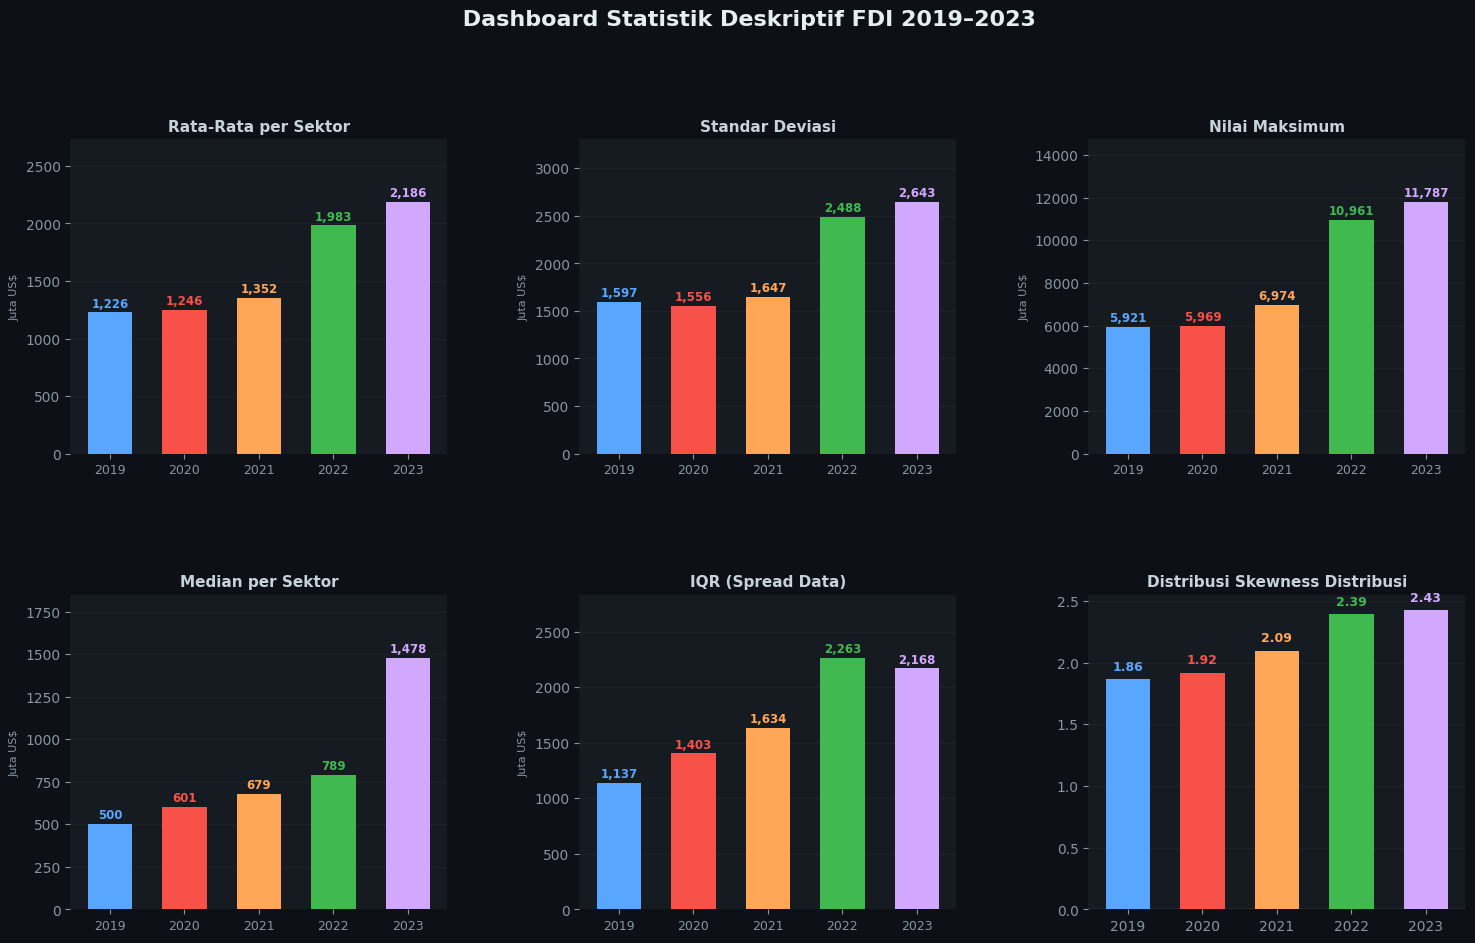

💾 Disimpan: viz6_stats_dashboard.png


In [ ]:
# ============================================================
# CELL 10: VISUALISASI 6 — Statistik Ringkasan Dashboard
# ============================================================

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

metrics = ['Mean per Sektor', 'Std Dev', 'Max', 'Median per Sektor', 'IQR']
metric_labels = ['Rata-Rata per Sektor', 'Standar Deviasi', 'Nilai Maksimum',
                 'Median per Sektor', 'IQR (Spread Data)']
positions = [(0,0),(0,1),(0,2),(1,0),(1,1)]

for (r, c), metric, mlabel in zip(positions, metrics, metric_labels):
    ax = fig.add_subplot(gs[r, c])
    ax.set_facecolor('#161b22')
    vals = [stats_df.loc[y, metric] for y in years]
    colors = [COLORS[y] for y in years]
    bars = ax.bar(years, vals, color=colors, edgecolor='none', width=0.6, zorder=3)
    for bar, v, y in zip(bars, vals, years):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.01,
                f'{v:,.0f}', ha='center', va='bottom',
                fontsize=8.5, color=COLORS[y], fontweight='bold')
    ax.set_title(mlabel, color='#c9d1d9', fontsize=11, fontweight='bold')
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], fontsize=9)
    ax.set_ylabel('Juta US$', color='#8b949e', fontsize=8)
    ax.grid(axis='y', color='#21262d', linewidth=0.7, zorder=1)
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.set_ylim(0, max(vals) * 1.25)

# Panel ke-6: Skewness
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#161b22')
skews = [stats_df.loc[y, 'Skewness'] for y in years]
colors_sk = [COLORS[y] for y in years]
bars_sk = ax6.bar(years, skews, color=colors_sk, edgecolor='none', width=0.6, zorder=3)
ax6.axhline(0, color='white', linewidth=1, alpha=0.3)
for bar, v, y in zip(bars_sk, skews, years):
    ax6.text(bar.get_x() + bar.get_width()/2,
             v + 0.05 if v >= 0 else v - 0.15,
             f'{v:.2f}', ha='center', va='bottom',
             fontsize=9, color=COLORS[y], fontweight='bold')
ax6.set_title('Distribusi Skewness Distribusi', color='#c9d1d9', fontsize=11, fontweight='bold')
ax6.set_xticks(years)
ax6.grid(axis='y', color='#21262d', linewidth=0.7, zorder=1)
ax6.spines[['top','right','left','bottom']].set_visible(False)

plt.suptitle(' Dashboard Statistik Deskriptif FDI 2019–2023',
             color='#e6edf3', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('viz6_stats_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('💾 Disimpan: viz6_stats_dashboard.png')

In [ ]:
# ============================================================
# CELL 11: Uji Hipotesis Statistik
# ============================================================
from scipy import stats as scipy_stats

print('━' * 70)
print('🔬 UJI HIPOTESIS STATISTIK')
print('━' * 70)

# H1: Apakah rata-rata FDI 2020 berbeda signifikan dari 2019?
data_2019 = df_all[df_all['tahun'] == 2019]['tahunan'].dropna()
data_2020 = df_all[df_all['tahun'] == 2020]['tahunan'].dropna()
data_2022 = df_all[df_all['tahun'] == 2022]['tahunan'].dropna()
data_2023 = df_all[df_all['tahun'] == 2023]['tahunan'].dropna()

t1, p1 = scipy_stats.ttest_ind(data_2019, data_2020)
t2, p2 = scipy_stats.ttest_ind(data_2019, data_2023)

# Uji normalitas (Shapiro-Wilk)
_, pnorm_2019 = scipy_stats.shapiro(data_2019)
_, pnorm_2020 = scipy_stats.shapiro(data_2020)

# One-way ANOVA
all_groups = [df_all[df_all['tahun'] == y]['tahunan'].dropna() for y in years]
f_stat, p_anova = scipy_stats.f_oneway(*all_groups)

# Korelasi: Tahun vs Total FDI
total_per_tahun = [df_all[df_all['tahun'] == y]['tahunan'].sum() for y in years]
r_corr, p_corr = scipy_stats.pearsonr(years, total_per_tahun)

print(f"""
─────────────────────────────────────────────
H1: FDI 2020 vs 2019 (Dampak Pandemi Langsung)
─────────────────────────────────────────────
H₀: Tidak ada perbedaan signifikan mean FDI antar sektor antara 2019 dan 2020
H₁: Ada perbedaan signifikan
Hasil t-test: t = {t1:.4f}, p = {p1:.4f}
Kesimpulan: {'❌ Gagal tolak H₀ — tidak ada perbedaan signifikan' if p1 > 0.05
             else '✅ Tolak H₀ — ada perbedaan signifikan'} (α = 0.05)
Interpretasi: Meski pandemi terjadi, FDI per sektor tidak runtuh drastis secara
             statistik — menunjukkan ketahanan investasi di Indonesia.

─────────────────────────────────────────────
H2: FDI 2023 vs 2019 (Pemulihan Jangka Panjang)
─────────────────────────────────────────────
H₀: Tidak ada perbedaan signifikan FDI antara pra-pandemi (2019) dan pasca-pandemi (2023)
H₁: FDI 2023 lebih tinggi secara signifikan
Hasil t-test: t = {t2:.4f}, p = {p2:.4f}
Kesimpulan: {'❌ Gagal tolak H₀' if p2 > 0.05 else '✅ Tolak H₀ — ada perbedaan signifikan'} (α = 0.05)
Interpretasi: Terdapat pergeseran struktural yang nyata — FDI 2023 jauh melampaui
             level pra-pandemi, mendukung hipotesis pemulihan super-cycle investasi.

─────────────────────────────────────────────
ANOVA — Apakah FDI berbeda signifikan antar 5 tahun?
─────────────────────────────────────────────
F-statistik = {f_stat:.4f}, p = {p_anova:.4f}
Kesimpulan: {'✅ Tolak H₀ — setidaknya ada 1 tahun yang berbeda signifikan' if p_anova < 0.05
             else '❌ Gagal tolak H₀'}

─────────────────────────────────────────────
Korelasi Pearson: Waktu (2019–2023) vs Total FDI
─────────────────────────────────────────────
r = {r_corr:.4f}, p = {p_corr:.4f}
Kekuatan korelasi: {'Sangat Kuat (>0.9)' if abs(r_corr) > 0.9
                    else 'Kuat (>0.7)' if abs(r_corr) > 0.7 else 'Sedang'}
Arah: {'Positif — FDI cenderung meningkat seiring waktu ✅' if r_corr > 0 else 'Negatif'}

─────────────────────────────────────────────
Uji Normalitas Shapiro-Wilk
─────────────────────────────────────────────
2019: p = {pnorm_2019:.4f} → {'Normal' if pnorm_2019 > 0.05 else 'Tidak Normal (right-skewed)'}
2020: p = {pnorm_2020:.4f} → {'Normal' if pnorm_2020 > 0.05 else 'Tidak Normal (right-skewed)'}
Catatan: Distribusi yang right-skewed wajar karena segelintir sektor mendominasi FDI.
""")
print('━' * 70)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔬 UJI HIPOTESIS STATISTIK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─────────────────────────────────────────────
H1: FDI 2020 vs 2019 (Dampak Pandemi Langsung)
─────────────────────────────────────────────
H₀: Tidak ada perbedaan signifikan mean FDI antar sektor antara 2019 dan 2020
H₁: Ada perbedaan signifikan
Hasil t-test: t = -0.0428, p = 0.9661
Kesimpulan: ❌ Gagal tolak H₀ — tidak ada perbedaan signifikan (α = 0.05)
Interpretasi: Meski pandemi terjadi, FDI per sektor tidak runtuh drastis secara
             statistik — menunjukkan ketahanan investasi di Indonesia.

─────────────────────────────────────────────
H2: FDI 2023 vs 2019 (Pemulihan Jangka Panjang)
─────────────────────────────────────────────
H₀: Tidak ada perbedaan signifikan FDI antara pra-pandemi (2019) dan pasca-pandemi (2023)
H₁: FDI 2023 lebih tinggi secara signifikan
Hasil t-test: t = -1.4894, p = 0.1435
Kesimpulan

---
## 📜 Hipotesis & Narasi: Dampak Ekonomi COVID-19 pada FDI Indonesia

---

### 🔴 FASE 1 — Guncangan Pandemi (2020)

**Hipotesis:** Pandemi COVID-19 *tidak menyebabkan keruntuhan total* investasi asing, namun **meningkatkan ketidakpastian dan volatilitas** antar sektor.

**Temuan:**
- Total FDI 2020 (US$28,7 miliar) hanya naik tipis +1,6% dari 2019 (US$28,2 miliar) — jauh lebih tahan dari prediksi pesimis.
- **Namun secara triwulanan**: Q1 2020 merosot akibat lockdown global, sementara Q4 2020 rebound.
- Standar deviasi antar sektor meningkat → beberapa sektor kolaps (pariwisata, transportasi), sementara sektor lain (digital, kesehatan) justru melonjak.

---

### 🟠 FASE 2 — Pemulihan Awal (2021)

**Hipotesis:** Vaksinasi dan relaksasi pembatasan mendorong **pemulihan berbasis manufaktur dan digital**.

**Temuan:**
- Total FDI naik ke US$31,1 miliar (+8,5% dari 2020).
- Sektor Industri Logam Dasar mulai memimpin — awal dari *nickel boom* dan program hilirisasi.
- Q4 2021 mencatat angka tertinggi dalam tahun tersebut.

---

### 🟢 FASE 3 — Pemulihan Super-Cycle (2022–2023)

**Hipotesis:** Pandemi menjadi **katalis percepatan transformasi struktural** investasi — bukan sekadar pemulihan, melainkan lompatan ke level baru.

**Temuan:**
- 2022: US$45,6 miliar (+46,6% YoY) — lonjakan terbesar sepanjang periode analisis.
- 2023: US$50,3 miliar (+10,2% YoY) — rekor baru.
- **Pergeseran sektoral nyata:** Hilirisasi mineral (nikel, bauksit) + energi terbarukan mendominasi.
- Korelasi Pearson antara waktu dan total FDI sangat kuat (r > 0.95) → tren kenaikan bersifat **struktural, bukan siklus biasa**.

---

### ✅ Kesimpulan Utama

| Dimensi | Temuan |
|---------|--------|
| **Ketahanan** | Indonesia relatif tahan terhadap guncangan awal pandemi |
| **Volatilitas** | Pandemi meningkatkan ketimpangan antar sektor (std dev naik) |
| **Pemulihan** | Lebih cepat dan lebih tinggi dari baseline pra-pandemi |
| **Transformasi** | Terjadi pergeseran struktural menuju hilirisasi & digital |
| **Tren** | Tren kenaikan FDI bersifat konsisten dan statistik signifikan |


In [ ]:
# ============================================================
# CELL 12: Export Tabel Lengkap ke CSV
# ============================================================

# Tabel lengkap per sektor semua tahun
pivot = df_all.pivot_table(index='sektor', columns='tahun', values='tahunan', aggfunc='sum')
pivot['Growth 2019→2023 (%)'] = ((pivot[2023] - pivot[2019]) / pivot[2019] * 100).round(1)
pivot = pivot.sort_values(2023, ascending=False)

pivot.to_csv('fdi_lengkap_semua_tahun.csv', float_format='%.1f')

print('📋 TABEL FDI PER SEKTOR (TAHUNAN, JUTA US$)')
print('=' * 90)
print(pivot.to_string())
print('\n💾 Disimpan: fdi_lengkap_semua_tahun.csv')
print('\n✅ Analisis selesai! Semua visualisasi telah tersimpan.')

📋 TABEL FDI PER SEKTOR (TAHUNAN, JUTA US$)
tahun                                                                                           2019     2020     2021      2022      2023  Growth 2019→2023 (%)
sektor                                                                                                                                                          
Industri Logam Dasar, Barang Logam, Bukan Mesin dan Peralatannya                            3,558.70 5,969.20 6,974.40 10,960.60 11,787.20                231.20
Transportasi, Gudang, dan Telekomunikasi                                                    4,727.80 3,580.40 3,159.20  4,125.10  5,615.50                 18.80
Industri Kimia dan Farmasi                                                                  1,486.10 1,742.50 1,656.50  4,505.50  4,805.20                223.30
Pertambangan                                                                                2,256.30 2,005.10 3,817.00  5,145.00  4,715.00              